# Part 1

In [55]:
import os
import tarfile
import urllib.request
import re
import numpy as np
import pandas as pd
import email
import email.policy

import matplotlib.pyplot as plt

from collections import Counter
from scipy.sparse import csr_matrix
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline

from sklearn.metrics import classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
DOWNLOAD_ROOT = "http://spamassassin.apache.org/old/publiccorpus/"
HAM_URL = DOWNLOAD_ROOT + "20030228_easy_ham.tar.bz2"
SPAM_URL = DOWNLOAD_ROOT + "20030228_spam.tar.bz2"

In [3]:
def fetch_spam_data():
    for url in (HAM_URL, SPAM_URL):
        filename = url.rsplit("/", 1)[-1]
        if not os.path.isfile(filename):
            urllib.request.urlretrieve(url, filename)
        with tarfile.open(filename) as tar:
            tar.extractall()

In [4]:
fetch_spam_data()

/var/folders/97/wz8gbns96vxdd6bmdx_5zqf80000gn/T/ipykernel_97159/1295042759.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [33]:
HAM_DIR = "easy_ham"
SPAM_DIR = "spam"

def load_email(directory, filename):
    path = os.path.join(directory, filename)
    with open(path, "rb") as f:
        return email.parser.BytesParser(policy=email.policy.default).parse(f)

In [34]:
ham_filenames = [f for f in sorted(os.listdir(HAM_DIR)) if len(f) > 20]
spam_filenames = [f for f in sorted(os.listdir(SPAM_DIR)) if len(f) > 20]

In [25]:
ham_emails = [load_email(HAM_DIR, f) for f in ham_filenames]
spam_emails = [load_email(SPAM_DIR, f) for f in spam_filenames]

In [35]:
ham_emails = [load_email(HAM_DIR, f) for f in ham_filenames]
spam_emails = [load_email(SPAM_DIR, f) for f in spam_filenames]

In [36]:
X = np.array(ham_emails + spam_emails, dtype=object)
y = np.array([0] * len(ham_emails) + [1] * len(spam_emails))

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [38]:
X_train

array([<email.message.EmailMessage object at 0x1529cd6d0>,
       <email.message.EmailMessage object at 0x1535abed0>, ...,
      shape=(2400,), dtype=object)

In [39]:
y_train

array([0, 0, 0, ..., 0, 1, 0], shape=(2400,))

In [17]:
def email_to_text(email):
    for part in email.walk():
        ctype = part.get_content_type()
        if ctype not in ("text/plain", "text/html"):
            continue
        try:
            content = part.get_content()
        except:
            content = str(part.get_payload())
        if ctype == "text/plain":
            return content
        else:
            return re.sub('<[^<]+?>', '', content)
    return ""

In [52]:
train_df = pd.DataFrame({
    'Subject': [e.get('Subject', 'No Subject') for e in X_train],
    'Content_Preview': [email_to_text(e)[:100].replace('\n', ' ') for e in X_train],
    'Target': y_train
})

print("--- Training Data Sample ---")
display(train_df.head())
print("\n--- Target Distribution (Proportions) ---")
print(train_df['Target'].value_counts(normalize=True))

--- Training Data Sample ---


,Subject,Content_Preview,Target
0,Re: Canadians,">>>>> ""R"" == Russell Turpin <deafbox@hotmail.c...",0
1,[use Perl] Stories for 2002-08-31,use Perl Daily Newsletter In this issue: ...,0
2,[Spambayes] XTreme Training,"On 10 September 2002, Tim Peters said: > Why w...",0
3,Re: Python 2.2 site libs?,"On Thu, 2002-10-03 at 08:16, Mark Derricutt wr...",0
4,[Razor-users] Forged email address,I received a spam email that had apparently fo...,0



--- Target Distribution (Proportions) ---
Target
0    0.833333
1    0.166667
Name: proportion, dtype: float64


In [44]:
class EmailToWordCounterTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, strip_headers=True, lower_case=True, remove_punctuation=True, 
                 replace_urls=True, replace_numbers=True, stemming=True):
        self.strip_headers = strip_headers
        self.lower_case = lower_case
        self.remove_punctuation = remove_punctuation
        self.replace_urls = replace_urls
        self.replace_numbers = replace_numbers
        self.stemming = stemming
        self.stemmer = PorterStemmer()

    def fit(self, X, y=None):
        return self

    def transform(self, X, y=None):
        X_transformed = []
        for email_obj in X:
            text = email_to_text(email_obj) or ""
            if not self.strip_headers:
                text = str(email_obj.as_string()) + text
            if self.lower_case: text = text.lower()
            if self.replace_urls: text = re.sub(r'(http|https)://[^\s]*', 'URL', text)
            if self.replace_numbers: text = re.sub(r'\d+', 'NUMBER', text)
            if self.remove_punctuation: text = re.sub(r'\W+', ' ', text, flags=re.M)
            
            word_counts = Counter(text.split())
            if self.stemming:
                stemmed_counts = Counter()
                for word, count in word_counts.items():
                    stemmed_counts[self.stemmer.stem(word)] += count
                word_counts = stemmed_counts
            X_transformed.append(word_counts)
        return X_transformed

In [41]:
class WordCountToVectorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, vocabulary_size=1000):
        self.vocabulary_size = vocabulary_size
        
    def fit(self, X, y=None):
        total_counts = Counter()
        for word_counts in X:
            for word, count in word_counts.items():
                total_counts[word] += count
        most_common = total_counts.most_common(self.vocabulary_size)
        self.vocabulary_ = {word: index + 1 for index, (word, count) in enumerate(most_common)}
        return self

    def transform(self, X, y=None):
        rows, cols, data = [], [], []
        for row, word_counts in enumerate(X):
            for word, count in word_counts.items():
                col = self.vocabulary_.get(word, 0)
                if col:
                    rows.append(row)
                    cols.append(col)
                    data.append(count)
        return csr_matrix((data, (rows, cols)), shape=(len(X), self.vocabulary_size + 1))

In [20]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score

In [46]:
full_pipeline = Pipeline([
    ("email_to_wordcount", EmailToWordCounterTransformer()),
    ("wordcount_to_vector", WordCountToVectorTransformer()),
])

In [47]:
X_train_transformed = full_pipeline.fit_transform(X_train)
X_test_transformed = full_pipeline.transform(X_test)

In [48]:
models = {
    "Logistic Regression": LogisticRegression(solver="liblinear", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM (Linear)": SVC(kernel="linear", random_state=42)
}

print(f"{'Model':<20} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 65)

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    y_pred = model.predict(X_test_transformed)
    
    print(f"{name:<20} | {precision_score(y_test, y_pred):<10.2%} | "
          f"{recall_score(y_test, y_pred):<10.2%} | {f1_score(y_test, y_pred):<10.2%}")

Model                | Precision  | Recall     | F1-Score  
-----------------------------------------------------------------
Logistic Regression  | 97.94%     | 95.00%     | 96.45%    
Random Forest        | 100.00%    | 87.00%     | 93.05%    
SVM (Linear)         | 96.91%     | 94.00%     | 95.43%    


--- Metrics Report ---

Model: Logistic Regression
------------------------------
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       500
        Spam       0.98      0.95      0.96       100

    accuracy                           0.99       600
   macro avg       0.98      0.97      0.98       600
weighted avg       0.99      0.99      0.99       600


Model: Random Forest
------------------------------
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       500
        Spam       1.00      0.87      0.93       100

    accuracy                           0.98       600
   macro avg       0.99      0.94      0.96       600
weighted avg       0.98      0.98      0.98       600


Model: SVM (Linear)
------------------------------
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       500
        Spam       0.97      0.94      0.95       

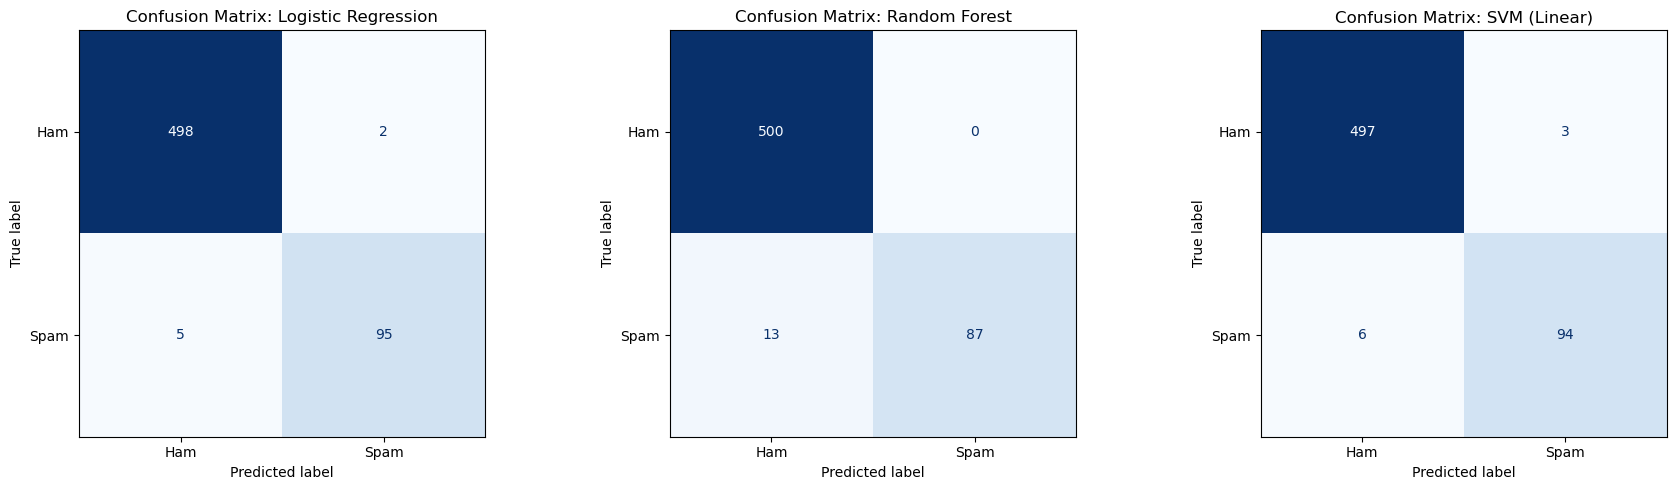

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (name, model) in enumerate(models.items()):
    # Get predictions for the test set
    y_pred = model.predict(X_test_transformed)
    
    cm = confusion_matrix(y_test, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
    disp.plot(ax=axes[i], cmap='Blues', values_format='d', colorbar=False)
    
    axes[i].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()

# Part 2

One of the first things I learned is that real-world data is rarely perfectly balanced. In this notebook, I saw that 83.3% of the emails were "Ham" (legitimate) and only 16.7% were "Spam". Because of this, simply using "Accuracy" as a metric could be misleading. I had to use a Stratified Split to make sure that both my training and testing sets had the same ratio of spam to ham so the model wouldn't get biased.

I experimented with three different classifiers to see which one could handle this data best:

- Logistic Regression was actually the most effective overall. It reached a 95% Recall, meaning it was the best at catching actual spam emails before they hit the inbox.

- Random Forest was interesting because it achieved a 100% Precision. This means it never accidentally labeled a legitimate email as spam. However, its Recall was lower (87%), meaning it was a bit too "cautious" and let more spam slip through.

- SVM (Linear) performed very similarly to Logistic Regression, showing that linear models are often really strong for text-based tasks.

Instead of just looking at a single number, I learned to use the classification_report. It showed me that all models were nearly perfect at identifying "Ham" (99% to 100% recall). The real challenge for the models was the "Spam" class, where the f1-scores ranged from 0.93 to 0.96. This taught me that the minority class (Spam) is where the "battle" is won or lost in a classifier.